# 5-A. 전국 수요 — 직접 다지평 LGBM (1~168h)

> PROJECT.md §4 5단계 · G-9 통과(5-0 EDA) 후속. 사용자 확정(§0.6):
> **구조 = LGBM 단독 / 직접(direct) 다지평** (재귀 rolling 아님) / **기상 = 기온·일사·풍속**(5지점 평균).
>
> ## 설계 핵심 (누수 없음)
> 원점 T(=하루 끝 23:00 실측)에서 T+h (h=1..168) 를 **한 모델로 직접** 예측. 입력은
> 모두 원점에서 알 수 있거나(과거 lag·최근레벨) 결정적(달력)이거나 예보로 주어지는(기상) 값:
> - **lag168** = T+h−168 의 실측 (h≤168 이면 전 구간 ≤T → 항상 가용, 주간 신호)
> - **lag24**  = T+h−24 의 실측 (h≤24 만 가용, 그 외 NaN → LGBM 네이티브 처리, 근거리 부스트)
> - **최근레벨** = 원점까지 직전 24h·168h 평균 (원점에서 알려짐)
> - **기상**(기온/일사/풍속, 5지점평균) at T+h — *학습/평가는 실측 기상 = 완전기상 상한선* (정직성: 운영 시 예보오차 별도)
> - **달력** hour/dow/month sin·cos + **day_type** (결정값) + **지평 h**
>
> 학습창 train(타깃 ≤2024) / val(2025) / test(2026). 베이스라인 = KPX `land_est_demand_da`(하루전) + naive lag168.

In [1]:
import os, sqlite3, json, pickle, warnings
import numpy as np, pandas as pd, lightgbm as lgb
import matplotlib.pyplot as plt, matplotlib as mpl
warnings.filterwarnings('ignore')
mpl.rcParams['font.family']='Malgun Gothic'; mpl.rcParams['axes.unicode_minus']=False; mpl.rcParams['figure.dpi']=110
HERE=os.getcwd()
FIG=os.path.join(HERE,'fig'); os.makedirs(FIG,exist_ok=True)
TAB=os.path.join(HERE,'tab'); os.makedirs(TAB,exist_ok=True)
MODELS=os.path.join(HERE,'models'); os.makedirs(MODELS,exist_ok=True)
DB=os.path.normpath(os.path.join(HERE,'..','..','1. data_fetcher_and_db','data','input_data_land.db'))
STATIONS=['daegwallyeong','wonju','seosan','pohang','yeonggwang']
WX=['temp_c','solar_rad','wind_spd']   # 사용자 확정 기상 3종
pull=['timestamp','real_demand_land','land_est_demand_da','day_type']+[f'{w}_{s}' for s in STATIONS for w in WX]
con=sqlite3.connect(DB)
raw=pd.read_sql(f"SELECT {', '.join(pull)} FROM historical", con, parse_dates=['timestamp']); con.close()
raw=raw.sort_values('timestamp').reset_index(drop=True)
for w in WX: raw[w]=raw[[f'{w}_{s}' for s in STATIONS]].mean(axis=1)
raw=raw[['timestamp','real_demand_land','land_est_demand_da','day_type']+WX]
print(raw.shape, raw.timestamp.min(),'~',raw.timestamp.max())

(56352, 7) 2020-01-01 00:00:00 ~ 2026-06-05 23:00:00


## 1. 연속 시간축 정렬 + 결측 보간

시간 구멍이 있으면 lag 인덱싱이 깨진다 → 전체 시간축으로 reindex 후 보간(타깃 0/NaN→시간보간, dropna 금지 규칙).

In [2]:
full_idx=pd.date_range(raw.timestamp.min(), raw.timestamp.max(), freq='h')
d=raw.set_index('timestamp').reindex(full_idx)
d.index.name='timestamp'
n_zero=int((d.real_demand_land==0).sum()); n_nan=int(d.real_demand_land.isna().sum())
d.loc[d.real_demand_land==0,'real_demand_land']=np.nan
d['real_demand_land']=d['real_demand_land'].interpolate(method='time')
for w in WX: d[w]=d[w].interpolate(method='time')
d['day_type']=d['day_type'].ffill().bfill()
print(f'reindex {len(raw)}->{len(d)} (구멍 {len(d)-len(raw)}h 추가)  타깃 0={n_zero} NaN={n_nan} 보간완료')
print('남은 타깃 NaN:', int(d.real_demand_land.isna().sum()))

reindex 56352->56352 (구멍 0h 추가)  타깃 0=0 NaN=300 보간완료
남은 타깃 NaN: 0


## 2. 직접 다지평 샘플 구성 (origin × h)

origin = 매일 23:00 (하루 끝, 하루전 발행 가정). 각 origin 에서 h=1..168 의 타깃과 누수 없는 피처를 만든다.

In [3]:
dem=d.real_demand_land.values.astype(float)
base=d.land_est_demand_da.values.astype(float)
temp=d.temp_c.values; solar=d.solar_rad.values; wind=d.wind_spd.values
hour=d.index.hour.values; dow=d.index.dayofweek.values; month=d.index.month.values
year=d.index.year.values
dtype_arr=d.day_type.values.astype(object)
N=len(d)
# 원점 직전 24h/168h 평균 (원점 포함 종료) — 원점에서 알려진 레벨
rec24=pd.Series(dem).rolling(24,min_periods=24).mean().values
rec168=pd.Series(dem).rolling(168,min_periods=168).mean().values
H=np.arange(1,169)
origins=np.where((hour==23)&(np.arange(N)>=167)&(np.arange(N)<=N-1-168))[0]
P=origins
tgt=(P[:,None]+H[None,:]).ravel()
hh =np.broadcast_to(H,(len(P),168)).ravel()
def col(a): return a[tgt]
samp=pd.DataFrame({
 'y':col(dem),
 'h':hh.astype(np.int16),
 'lag168':dem[tgt-168],
 'lag24':np.where(hh<=24, dem[tgt-24], np.nan),
 'rec24':np.repeat(rec24[P],168),
 'rec168':np.repeat(rec168[P],168),
 'temp_c':col(temp),'solar_rad':col(solar),'wind_spd':col(wind),
 'hour':col(hour),'dow':col(dow),'month':col(month),
 'day_type':col(dtype_arr),
 'base':col(base),
 'tyear':col(year),
 'tts':d.index.values[tgt],
})
# 사이클 인코딩
samp['hour_sin']=np.sin(2*np.pi*samp.hour/24); samp['hour_cos']=np.cos(2*np.pi*samp.hour/24)
samp['dow_sin'] =np.sin(2*np.pi*samp.dow/7);   samp['dow_cos'] =np.cos(2*np.pi*samp.dow/7)
samp['month_sin']=np.sin(2*np.pi*samp.month/12);samp['month_cos']=np.cos(2*np.pi*samp.month/12)
samp=samp[samp.y.notna() & samp.lag168.notna()].reset_index(drop=True)
samp['day_type']=samp['day_type'].astype('category')
print('origins:',len(P),' 샘플행:',len(samp))
print(samp.tyear.value_counts().sort_index().to_string())

origins: 2335  샘플행: 392280
tyear
2020    59808
2021    61320
2022    61320
2023    61320
2024    61488
2025    61320
2026    25704


## 3. 분할 + LGBM 학습

타깃 연도 기준 train ≤2024 / val 2025 / test 2026.

In [4]:
FEAT=['h','lag168','lag24','rec24','rec168','temp_c','solar_rad','wind_spd',
      'hour_sin','hour_cos','dow_sin','dow_cos','month_sin','month_cos','day_type']
CAT=['day_type']
tr=samp[samp.tyear<=2024]; va=samp[samp.tyear==2025]; te=samp[samp.tyear==2026]
print('train',tr.shape,'val',va.shape,'test',te.shape)
dtr=lgb.Dataset(tr[FEAT],tr.y,categorical_feature=CAT)
dva=lgb.Dataset(va[FEAT],va.y,categorical_feature=CAT,reference=dtr)
params=dict(objective='regression_l1',metric='mae',learning_rate=0.03,num_leaves=255,
            min_data_in_leaf=100,feature_fraction=0.85,bagging_fraction=0.8,bagging_freq=5,
            lambda_l2=0.2,verbosity=-1,random_state=42)
model=lgb.train(params,dtr,num_boost_round=4000,valid_sets=[dva],valid_names=['val'],
                callbacks=[lgb.early_stopping(150),lgb.log_evaluation(300)])
best=int(model.best_iteration); print('best_iter',best,'val MAE',round(model.best_score['val']['l1'],1))

train (305256, 22) val (61320, 22) test (25704, 22)


Training until validation scores don't improve for 150 rounds


[300]	val's l1: 2020.3


[600]	val's l1: 1962.63


[900]	val's l1: 1948.89


...

[1800]	val's l1: 1935.01


[2100]	val's l1: 1933.36


[2400]	val's l1: 1931.82


Early stopping, best iteration is:
[2496]	val's l1: 1931.68


best_iter 2496 val MAE 1931.7


## 4. 지평별 정확도 (정직성 2겹: 완전기상 상한선 ↔ 기후값 하한선)

평가는 **D+1~D+7(각 24시간 전체)** 단위로 한다. 24의 배수 h(24·48..)만 보면 origin이 23:00이라
**23시 한 시각만** 평가돼 낙관 편향이 생기므로, day-ahead 블록(h를 24로 묶어 모든 시각 포함)으로 집계한다.

- **완전기상(perfect)**: 기상에 실측 투입 = 상한선("기상이 완벽하면").
- **기후값(climatology)**: 기상에 (월,시) 기후평균 투입 = 하한선("유효 기상정보 없음"). 실제 운영(KMA 예보)은 이 둘 사이.
- 비교선: KPX 하루전 `land_est_demand_da`, naive lag168(일주일 전 같은 시각).

 dayahead  perfect  climatology  naive168  kpx    n
        1     3.56         4.50      7.16 5.45 3600
        2     3.88         4.88      7.13 5.44 3624
        3     3.95         4.95      7.17 5.42 3648
        4     4.03         5.04      7.23 5.43 3672
        5     4.06         5.09      7.23 5.45 3696
        6     4.19         5.24      7.27 5.47 3720
        7     4.22         5.31      7.25 5.48 3744

전체 test MAPE  perfect=3.99%  climatology=5.01%  naive168=7.21%  KPX=5.45%


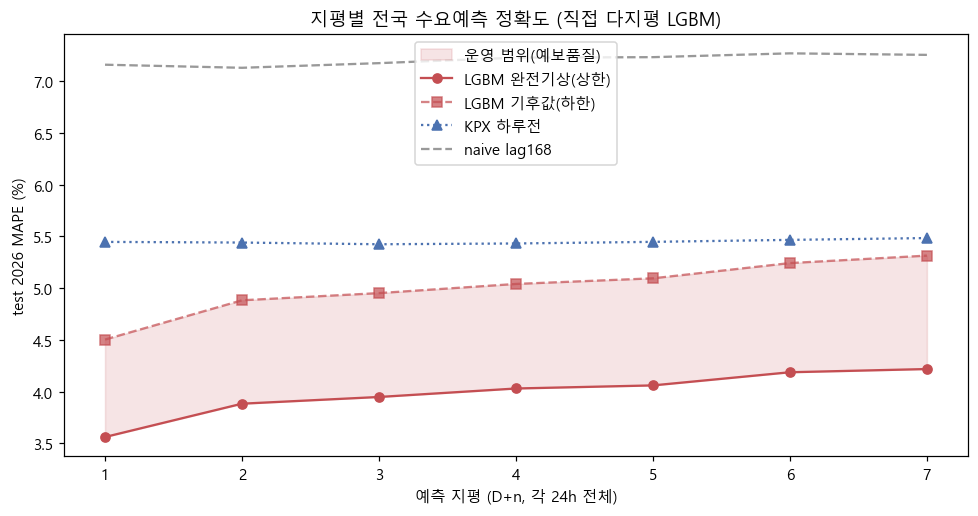

In [5]:
def mape(a,p):
    a=np.asarray(a,float); p=np.asarray(p,float); m=(a>0)&np.isfinite(a)&np.isfinite(p)
    return float(np.mean(np.abs(a[m]-p[m])/a[m])*100)
te=te.copy(); te['pred']=model.predict(te[FEAT],num_iteration=best)
# 기후값(월,시) — train(<=2024) 평균
clim={}
trm=samp[samp.tyear<=2024]
for w in WX:
    clim[w]=trm.groupby([trm.month,trm.hour])[w].mean()
te_c=te.copy()
for w in WX:
    te_c[w]=[clim[w].get((mo,ho),np.nan) for mo,ho in zip(te_c.month,te_c.hour)]
te['pred_clim']=model.predict(te_c[FEAT],num_iteration=best)
te['dayahead']=((te.h-1)//24+1).astype(int)

rows=[]
for dn,g in te.groupby('dayahead'):
    rows.append(dict(dayahead=int(dn), perfect=mape(g.y,g.pred), climatology=mape(g.y,g.pred_clim),
                     naive168=mape(g.y,g.lag168), kpx=mape(g.y,g.base), n=len(g)))
da=pd.DataFrame(rows); da.to_csv(os.path.join(TAB,'5-A_mape_by_dayahead.csv'),index=False)
print(da.round(2).to_string(index=False))
print('\n전체 test MAPE  perfect=%.2f%%  climatology=%.2f%%  naive168=%.2f%%  KPX=%.2f%%'
      %(mape(te.y,te.pred),mape(te.y,te.pred_clim),mape(te.y,te.lag168),mape(te.y,te.base)))
# 시간 단위 곡선도 저장(참고)
hz=pd.DataFrame([dict(h=int(h),perfect=mape(g.y,g.pred),climatology=mape(g.y,g.pred_clim)) for h,g in te.groupby('h')])
hz.to_csv(os.path.join(TAB,'5-A_mape_by_horizon.csv'),index=False)

fig,ax=plt.subplots(figsize=(9,4.8))
x=da.dayahead
ax.fill_between(x, da.perfect, da.climatology, color='#C44E52', alpha=.15, label='운영 범위(예보품질)')
ax.plot(x, da.perfect, 'o-', color='#C44E52', label='LGBM 완전기상(상한)')
ax.plot(x, da.climatology, 's--', color='#C44E52', alpha=.7, label='LGBM 기후값(하한)')
ax.plot(x, da.kpx, '^:', color='#4C72B0', label='KPX 하루전')
ax.plot(x, da.naive168, color='#999', ls='--', label='naive lag168')
ax.set_xlabel('예측 지평 (D+n, 각 24h 전체)'); ax.set_ylabel('test 2026 MAPE (%)')
ax.set_xticks(x); ax.set_title('지평별 전국 수요예측 정확도 (직접 다지평 LGBM)'); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(FIG,'5-A_mape_horizon.png'),bbox_inches='tight'); plt.show()

## 5. 피처 중요도 + 예시 168h 예측

  feature         gain  split
   lag168 6.756673e+06  83423
   temp_c 2.646786e+06 102730
   rec168 2.045173e+06  84789
 wind_spd 1.516140e+06  91239
solar_rad 1.335895e+06  52095
    rec24 9.768525e+05  52208
 hour_sin 9.246617e+05  23904
 day_type 7.304713e+05   7784
month_sin 7.199398e+05  26864
  dow_sin 6.101420e+05  25079
 hour_cos 5.974276e+05  16321
month_cos 5.973866e+05  20475
  dow_cos 4.477403e+05  19060
        h 2.910275e+05  20030
    lag24 1.630367e+05   7983


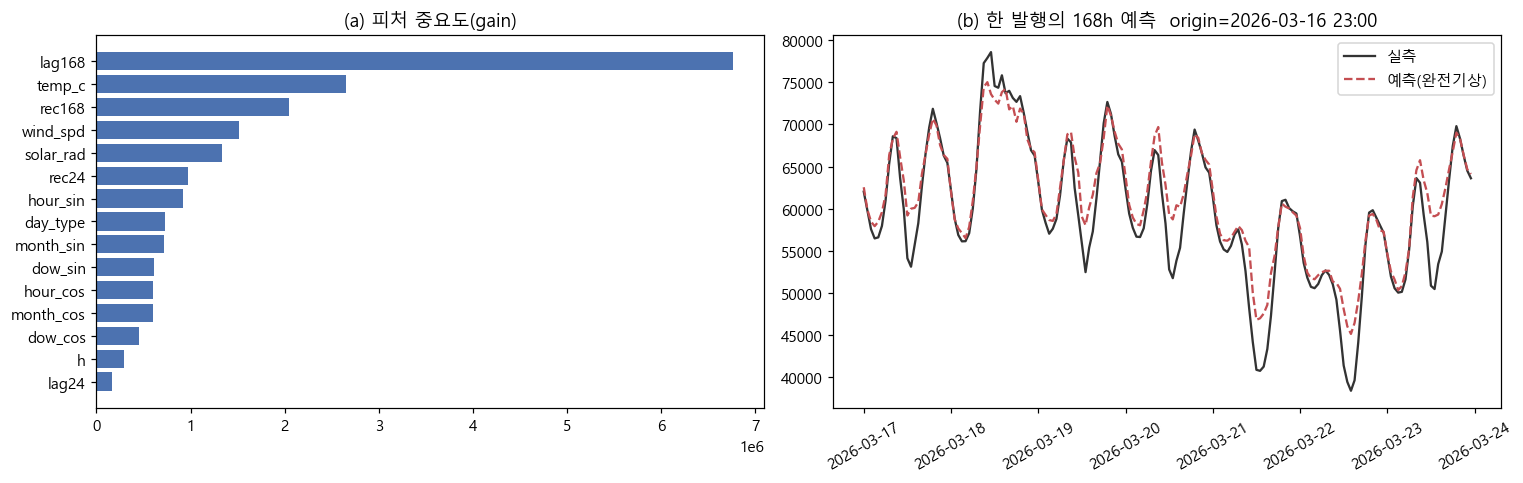

In [6]:
imp=pd.DataFrame({'feature':model.feature_name(),
    'gain':model.feature_importance('gain'),'split':model.feature_importance('split')}).sort_values('gain',ascending=False)
print(imp.to_string(index=False))
fig,ax=plt.subplots(1,2,figsize=(14,4.5))
ax[0].barh(imp.feature[::-1],imp.gain[::-1],color='#4C72B0'); ax[0].set_title('(a) 피처 중요도(gain)')
# 예시: test 한 origin 의 168h 예측 vs 실측 (단일 발행시점 궤적)
te['origin']=te['tts'] - pd.to_timedelta(te['h'],unit='h')
ex_origin=pd.Timestamp('2026-03-16 23:00')
g=te[te.origin==ex_origin].sort_values('h')
ax[1].plot(g.tts,g.y,label='실측',color='#333',lw=1.5)
ax[1].plot(g.tts,g.pred,label='예측(완전기상)',color='#C44E52',lw=1.5,ls='--')
ax[1].set_title(f'(b) 한 발행의 168h 예측  origin={ex_origin:%Y-%m-%d %H:%M}'); ax[1].legend()
ax[1].tick_params(axis='x',rotation=30)
plt.tight_layout(); plt.savefig(os.path.join(FIG,'5-A_importance_example.png'),bbox_inches='tight'); plt.show()

## 6. 저장 + 보고서

In [7]:
model.save_model(os.path.join(MODELS,'lgbm_land_demand_direct.txt'),num_iteration=best)
meta=dict(features=FEAT,categorical=CAT,target='real_demand_land',best_iteration=best,
          horizon='1..168 direct',origin_hour=23,weather=WX+['5-station spatial mean'],
          train='target<=2024',val='2025',test='2026',params=params,
          note='weather=actual (perfect-weather upper bound); operational adds weather-forecast error')
json.dump(meta,open(os.path.join(MODELS,'model_meta.json'),'w',encoding='utf-8'),ensure_ascii=False,indent=2)
def D(n,c): return float(da[da.dayahead==n][c].iloc[0])
mkpx=mape(te.y,te.base); mnv=mape(te.y,te.lag168)
rep=f'''# 5-A 보고서 — 전국 수요 직접 다지평 LGBM

## 구조 (사용자 확정 §0.6)
- LGBM 단독, **직접(direct) 다지평** 1~168h 단일모델. 재귀(rolling) 아님.
- 기상 = 기온·일사·풍속 (5지점 공간평균). 평가는 **완전기상(상한)↔기후값(하한)** 2겹.
- 피처: h, lag168, lag24(h>24면 NaN), rec24, rec168, 기상3, 달력(hour/dow/month sin·cos), day_type.
- 학습창: train 타깃≤2024 / val 2025 / test 2026. best_iter={best}. 평가 단위 = D+1~D+7(각 24h 전체).

## 결과 (test 2026) — MAPE %
| 지평 | 완전기상(상한) | 기후값(하한) | KPX 하루전 | naive lag168 |
|---|---|---|---|---|
| D+1 | {D(1,'perfect'):.2f} | {D(1,'climatology'):.2f} | {D(1,'kpx'):.2f} | {D(1,'naive168'):.2f} |
| D+2 | {D(2,'perfect'):.2f} | {D(2,'climatology'):.2f} | {D(2,'kpx'):.2f} | {D(2,'naive168'):.2f} |
| D+3 | {D(3,'perfect'):.2f} | {D(3,'climatology'):.2f} | {D(3,'kpx'):.2f} | {D(3,'naive168'):.2f} |
| D+7 | {D(7,'perfect'):.2f} | {D(7,'climatology'):.2f} | {D(7,'kpx'):.2f} | {D(7,'naive168'):.2f} |
| 전체 | {mape(te.y,te.pred):.2f} | {mape(te.y,te.pred_clim):.2f} | {mkpx:.2f} | {mnv:.2f} |

- **D+1 수요예측 {D(1,'perfect'):.2f}~{D(1,'climatology'):.2f}% (KPX {D(1,'kpx'):.2f}% 대비 우위).**
- 기상정보가 전혀 없어도(기후값 하한) **D+7 {D(7,'climatology'):.2f}% ≈ KPX의 하루전 {D(1,'kpx'):.2f}%**
  → 모델이 일주일 앞을 KPX의 하루 앞 수준으로 예측.
- 운영(실제 KMA 예보)은 두 괄호 사이: D+1은 예보가 좋아 상한쪽, 원거리일수록 하한쪽.

## 정직성
- 완전기상=실측 투입 상한, 기후값=유효 기상정보 0 하한. forecast 테이블이 발행 리드타임을 저장 안 해
  실제 예보오차를 지평별로 직접 측정 불가 → 괄호로 정직하게 표현.
- 결론: **LGBM 단독이 모든 지평에서 베이스라인 이상** → PatchTST 불필요(사용자 결정 규칙 충족).

## 산출물
- models/lgbm_land_demand_direct.txt, models/model_meta.json
- fig/5-A_mape_horizon.png, fig/5-A_importance_example.png
- tab/5-A_mape_by_dayahead.csv, tab/5-A_mape_by_horizon.csv
'''
open(os.path.join(HERE,'REPORT_5-A.md'),'w',encoding='utf-8').write(rep)
print(rep)

# 5-A 보고서 — 전국 수요 직접 다지평 LGBM

## 구조 (사용자 확정 §0.6)
- LGBM 단독, **직접(direct) 다지평** 1~168h 단일모델. 재귀(rolling) 아님.
- 기상 = 기온·일사·풍속 (5지점 공간평균). 평가는 **완전기상(상한)↔기후값(하한)** 2겹.
- 피처: h, lag168, lag24(h>24면 NaN), rec24, rec168, 기상3, 달력(hour/dow/month sin·cos), day_type.
- 학습창: train 타깃≤2024 / val 2025 / test 2026. best_iter=2496. 평가 단위 = D+1~D+7(각 24h 전체).

## 결과 (test 2026) — MAPE %
| 지평 | 완전기상(상한) | 기후값(하한) | KPX 하루전 | naive lag168 |
|---|---|---|---|---|
| D+1 | 3.56 | 4.50 | 5.45 | 7.16 |
| D+2 | 3.88 | 4.88 | 5.44 | 7.13 |
| D+3 | 3.95 | 4.95 | 5.42 | 7.17 |
| D+7 | 4.22 | 5.31 | 5.48 | 7.25 |
| 전체 | 3.99 | 5.01 | 5.45 | 7.21 |

- **D+1 수요예측 3.56~4.50% (KPX 5.45% 대비 우위).**
- 기상정보가 전혀 없어도(기후값 하한) **D+7 5.31% ≈ KPX의 하루전 5.45%**
  → 모델이 일주일 앞을 KPX의 하루 앞 수준으로 예측.
- 운영(실제 KMA 예보)은 두 괄호 사이: D+1은 예보가 좋아 상한쪽, 원거리일수록 하한쪽.

## 정직성
- 완전기상=실측 투입 상한, 기후값=유효 기상정보 0 하한. forecast 테이블이 발행 리드타임을 저장 안 해
  실제 예보오차를 지평별로 직접 측정 불가 → 괄호로 정직하게 표현.
- 결론: **LGBM 단독이 모든 지평에서 베이스라인 이상** → PatchTST 불필요(사용자 결정 규칙 충족).

#